# 03 — Sequence Models: MLP, LSTM & Hybrid (PyTorch)
Train and compare three neural network architectures on temporal
windows of SOLEY PV data:

| Architecture | Description |
|---|---|
| **MLP**    | Per-timestep features from the last step of the window |
| **LSTM**   | Bi-directional LSTM over the full window |
| **Hybrid** | MLP branch (last step) + LSTM branch fused (recommended) |

The streaming memmap pipeline keeps peak RAM ≈ 1 parquet file (~60–100 MB)
regardless of dataset size.


## 1. Imports & setup

In [1]:
import sys, pathlib, shutil
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from library.utils      import setup_logging, get_device, get_num_workers
from library.config     import BatchConfig
from library.data       import prepare_file_registry, assign_splits
from library.models.trainer import run_pytorch_task

setup_logging()
%matplotlib inline
plt.rcParams["figure.dpi"] = 120


## 2. Configuration

In [ ]:
DATA_DIR   = "data"
OUTPUT_DIR = "outputs/sequence_models"
pathlib.Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# Training hyperparameters
WINDOW_SIZE = 2016   # timesteps per sample (7 days × 24 h × 12 steps/h)
             # A 7-day context is realistic for fault monitoring:
             # gradual degradation (soiling, aging, EL darkening) manifests
             # over several days; an LSTM can learn those multi-day trends.
STRIDE      = 288    # step between windows (1 day = 288 × 5-min steps)
             # 1-day stride avoids excessive window overlap while still
             # producing ~350 training windows per 1-year run.
BATCH_SIZE  = 512    # reduced from 1024 because each sample is ~4× larger
EPOCHS      = 30
PATIENCE    = 7
MAX_RUNS    = None     # must match 02_random_forest.ipynb for fair comparison

# Model variants to train: "mlp", "lstm", "hybrid", or all three
MODEL_MODES = ["mlp", "lstm", "hybrid"]


In [3]:
cfg    = BatchConfig(DATA_DIR)
device = get_device()
n_workers = get_num_workers()
print(f"Device:  {device}")
print(f"Workers: {n_workers}")
print(cfg)


  Config: array=5.34 kWp, 6 location(s)
  God-mode columns found in data and excluded from all feature sets: ['detailed_balance_efficiency_pct', 'ff', 'jmpp_a_m2', 'jsc_a_m2', 'vmpp_v', 'voc_v']
  Columns: 11 SCADA, 8 device physics, 6 stress, 29 constant (excluded), 6 god-mode (excluded), 25 total features
Device: Apple MPS
Device:  mps
Workers: 4
BatchConfig(array_kwp=5.34, locations=6, features=25)


## 3. Build file registry & assign splits

In [4]:
# No data is loaded here — just file paths and fault-type metadata
registry = prepare_file_registry(DATA_DIR, cfg, max_runs=MAX_RUNS)
assign_splits(registry)

fault_types = sorted({e['fault_type'] for e in registry})
print(f"\nFault types in registry: {fault_types}")


Registry: 96 files, 12 fault types
  train: 72 files
  val: 12 files
  test: 12 files

Fault types in registry: ['bypass_diode_short', 'cell_crack', 'combo', 'connector_burnout', 'curtailment', 'mppt_failure', 'none', 'pid', 'sensor_drift', 'solder_fatigue', 'string_failure', 'sudden_soiling']


## 4. Feature list

In [5]:
# Use the same feature set as 02_random_forest.ipynb — identical call to
# cfg.feature_set("full") ensures both model families see the same inputs.
feature_list = cfg.feature_set("full")
print(f"Total features: {len(feature_list)}")


Total features: 33


## 5. Task A — Fault Detection (binary)

In [6]:
detection_reports = run_pytorch_task(
    task_name   = "Fault Detection",
    target_col  = "fault_active",
    registry    = registry,
    feature_cols= feature_list,
    model_modes = MODEL_MODES,
    window_size = WINDOW_SIZE,
    stride      = STRIDE,
    batch_size  = BATCH_SIZE,
    epochs      = EPOCHS,
    device      = device,
    output_dir  = OUTPUT_DIR,
    patience    = PATIENCE,
    cfg         = cfg,
    num_workers = n_workers,
)



  Fault Detection
  Classes: 2  Files: train=72, val=12, test=12
  Fitting scaler …
After daytime filter: 306,529 rows
After daytime filter: 307,790 rows
After daytime filter: 306,828 rows
After daytime filter: 306,809 rows
After daytime filter: 306,822 rows
After daytime filter: 306,416 rows
After daytime filter: 306,764 rows
After daytime filter: 306,834 rows
After daytime filter: 306,399 rows
After daytime filter: 306,824 rows
After daytime filter: 307,815 rows
After daytime filter: 307,992 rows
After daytime filter: 307,917 rows
After daytime filter: 307,824 rows
After daytime filter: 307,888 rows
After daytime filter: 307,610 rows
After daytime filter: 307,820 rows
After daytime filter: 307,420 rows
After daytime filter: 307,990 rows
After daytime filter: 307,575 rows
  Scaler fit on 20 files, 33 features
  Building train arrays (72 files) …
After daytime filter: 306,529 rows
After daytime filter: 306,678 rows
After daytime filter: 306,917 rows
After daytime filter: 307,790 rows



MLP training curves:


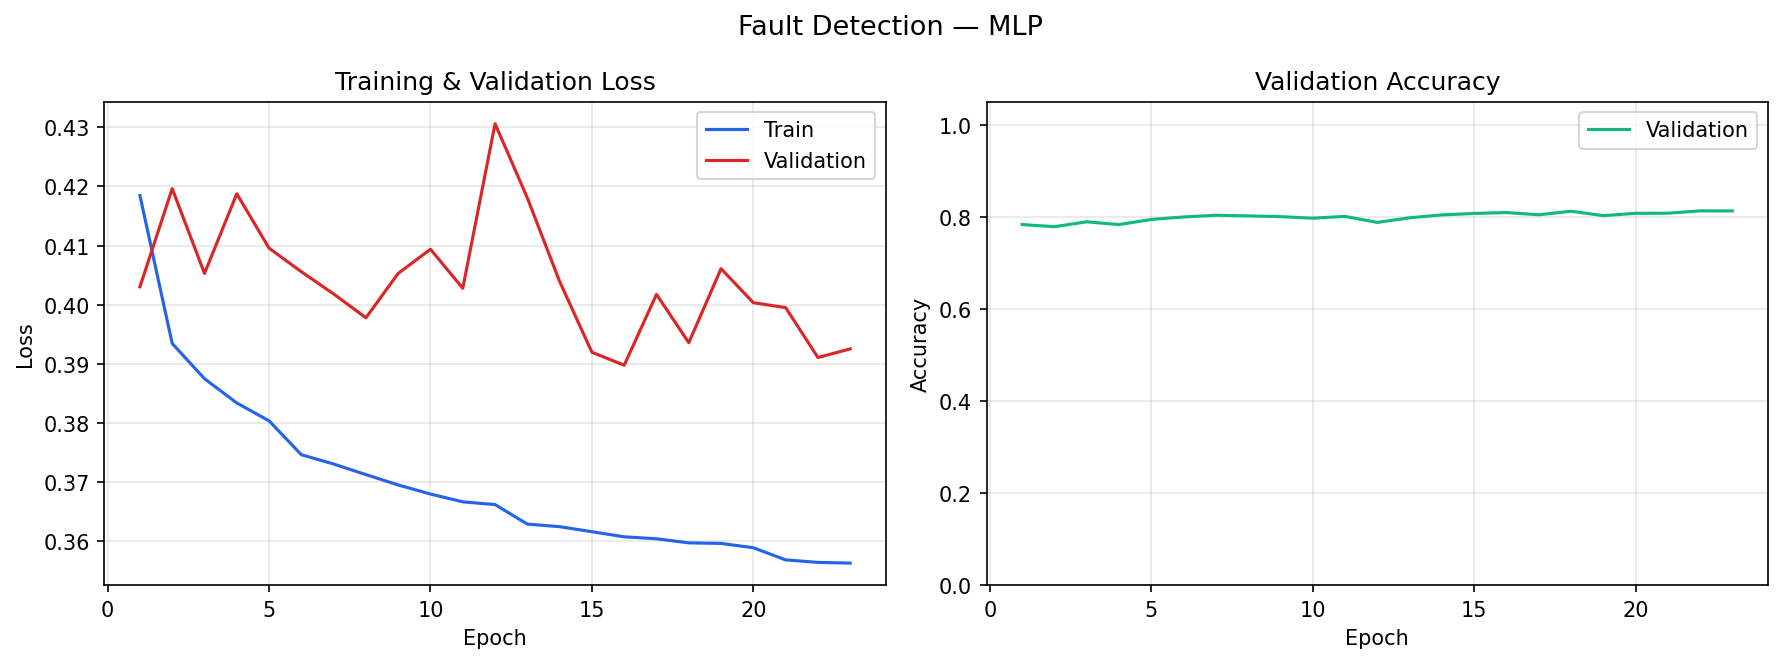


LSTM training curves:


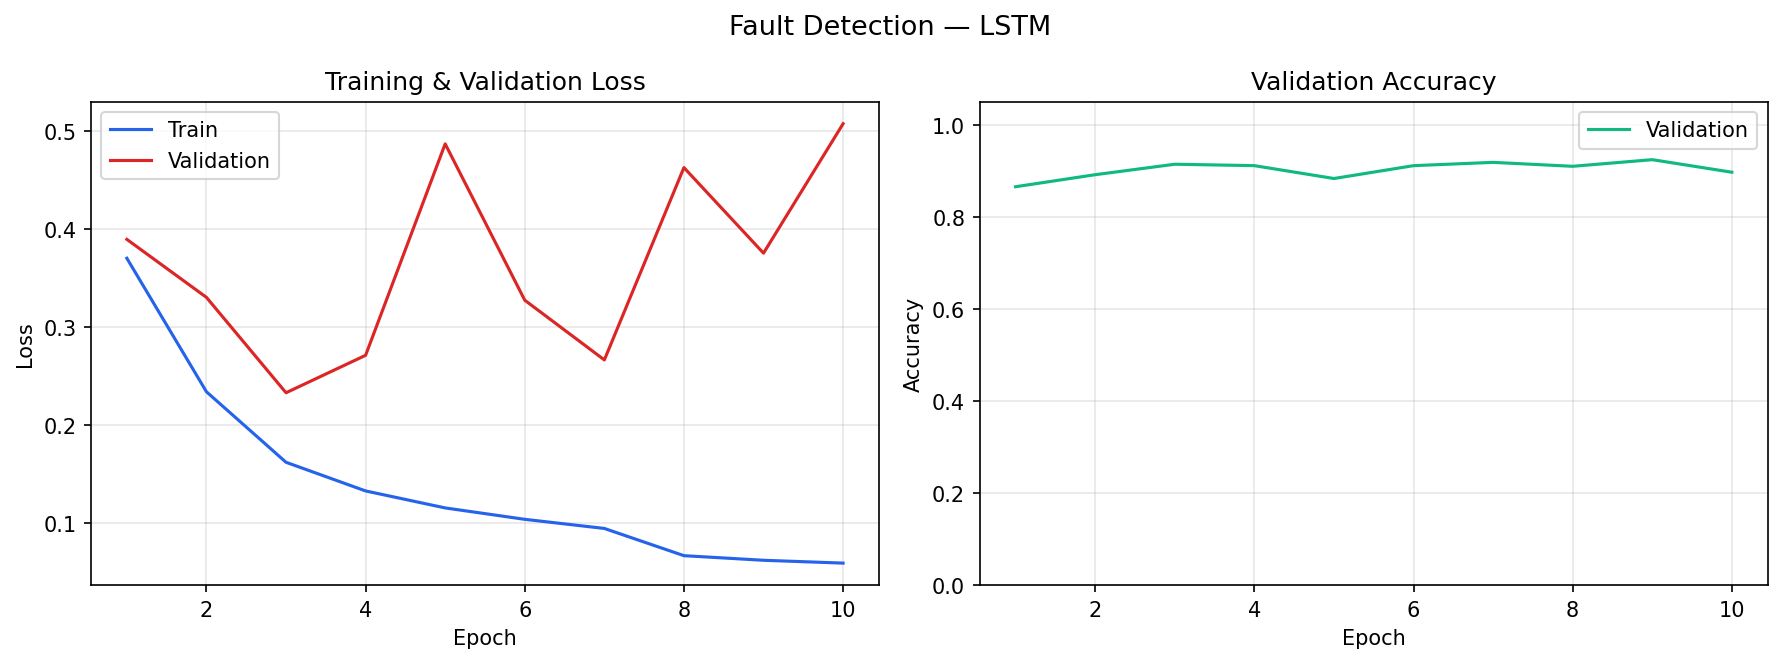


HYBRID training curves:


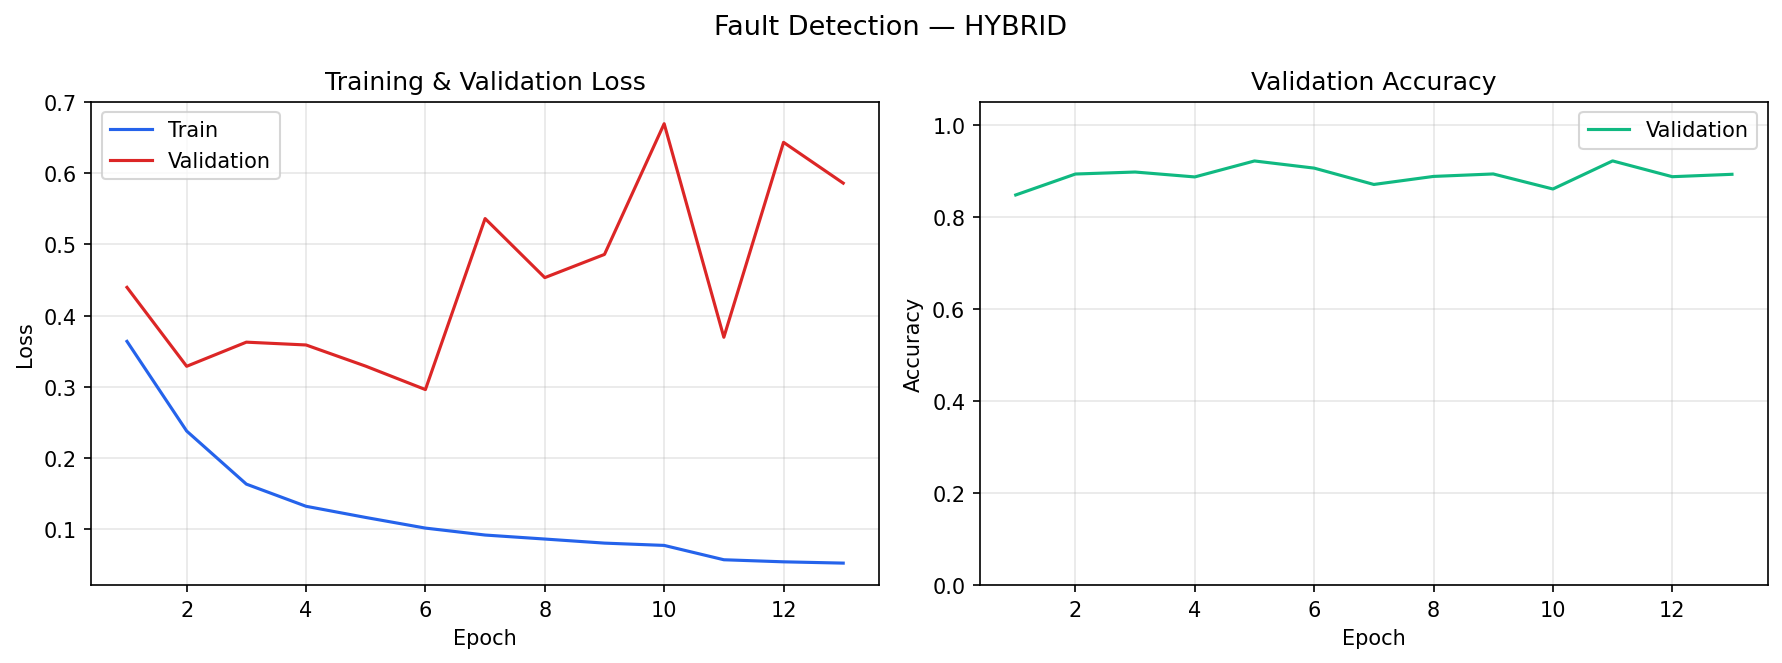

In [7]:
# Training curves
from IPython.display import Image, display as ipy_display
for mode in MODEL_MODES:
    p = f"{OUTPUT_DIR}/curves_fault_detection_{mode}.png"
    if pathlib.Path(p).exists():
        print(f"\n{mode.upper()} training curves:")
        ipy_display(Image(p))


## 6. Task B — Fault Classification (multi-class)

In [8]:
classification_reports = run_pytorch_task(
    task_name   = "Fault Classification",
    target_col  = "fault_type",
    registry    = registry,
    feature_cols= feature_list,
    model_modes = MODEL_MODES,
    window_size = WINDOW_SIZE,
    stride      = STRIDE,
    batch_size  = BATCH_SIZE,
    epochs      = EPOCHS,
    device      = device,
    output_dir  = OUTPUT_DIR,
    patience    = PATIENCE,
    cfg         = cfg,
    num_workers = n_workers,
)



  Fault Classification
  Classes: 11  Files: train=66, val=11, test=11
  Fitting scaler …
After daytime filter: 306,828 rows
After daytime filter: 306,809 rows
After daytime filter: 306,822 rows
After daytime filter: 306,416 rows
After daytime filter: 306,764 rows
After daytime filter: 306,834 rows
After daytime filter: 306,399 rows
After daytime filter: 306,824 rows
After daytime filter: 307,815 rows
After daytime filter: 307,992 rows
After daytime filter: 307,917 rows
After daytime filter: 307,824 rows
After daytime filter: 307,888 rows
After daytime filter: 307,610 rows
After daytime filter: 307,820 rows
After daytime filter: 307,420 rows
After daytime filter: 307,990 rows
After daytime filter: 307,575 rows
After daytime filter: 307,283 rows
After daytime filter: 307,537 rows
  Scaler fit on 20 files, 33 features
  Building train arrays (66 files) …
After daytime filter: 306,828 rows
After daytime filter: 306,687 rows
After daytime filter: 306,846 rows
After daytime filter: 306,809

Python(15876) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15877) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15878) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15879) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15912) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15913) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15914) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15915) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  Epoch   1/30  train_loss=0.8790  val_loss=0.6781  val_acc=0.7139
  Epoch   2/30  train_loss=0.6481  val_loss=0.6271  val_acc=0.7144
  Epoch   3/30  train_loss=0.6062  val_loss=0.5660  val_acc=0.7351
  Epoch   4/30  train_loss=0.5795  val_loss=0.5505  val_acc=0.7341
  Epoch   5/30  train_loss=0.5630  val_loss=0.5822  val_acc=0.7194
  Epoch   6/30  train_loss=0.5495  val_loss=0.5342  val_acc=0.7420
  Epoch   7/30  train_loss=0.5396  val_loss=0.5249  val_acc=0.7509
  Epoch   8/30  train_loss=0.5291  val_loss=0.5429  val_acc=0.7428
  Epoch   9/30  train_loss=0.5245  val_loss=0.5311  val_acc=0.7509
  Epoch  10/30  train_loss=0.5149  val_loss=0.5070  val_acc=0.7633
  Epoch  11/30  train_loss=0.5109  val_loss=0.5046  val_acc=0.7702
  Epoch  12/30  train_loss=0.5044  val_loss=0.4807  val_acc=0.7792
  Epoch  13/30  train_loss=0.5015  val_loss=0.5087  val_acc=0.7602
  Epoch  14/30  train_loss=0.4970  val_loss=0.5173  val_acc=0.7621
  Epoch  15/30  train_loss=0.4933  val_loss=0.5035  val_acc=0.

Python(16271) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(16272) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(16273) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(16274) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



                    precision    recall  f1-score   support

bypass_diode_short       1.00      1.00      1.00     21533
        cell_crack       0.93      0.90      0.92     21204
             combo       0.99      0.88      0.93     25591
 connector_burnout       1.00      0.98      0.99     22565
       curtailment       0.58      0.96      0.72      3173
      mppt_failure       0.79      0.74      0.77     15128
               pid       0.10      0.06      0.07     25648
      sensor_drift       0.51      0.80      0.62     25557
    solder_fatigue       0.48      0.39      0.43     22602
    string_failure       0.74      0.77      0.75     15848
    sudden_soiling       0.20      0.26      0.23      5029

          accuracy                           0.71    203878
         macro avg       0.66      0.70      0.68    203878
      weighted avg       0.70      0.71      0.69    203878

  ROC AUC: 0.9595
  Saved confusion_fault_classification_mlp.png
  Saved: model_fault_classifica

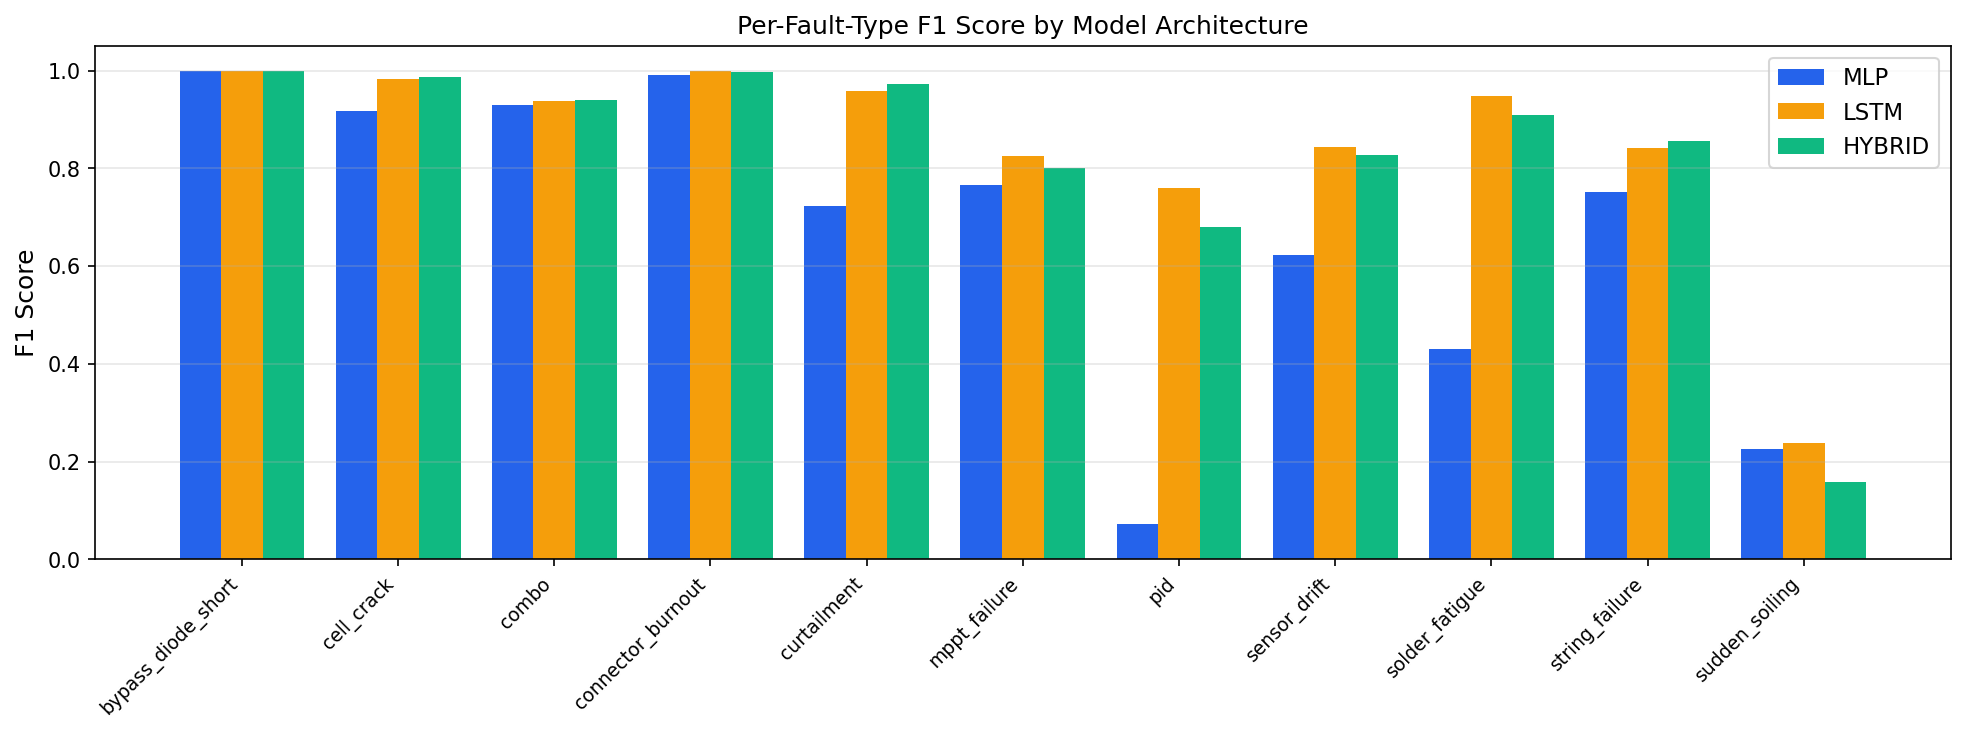

In [9]:
# Per-fault F1 comparison
p = f"{OUTPUT_DIR}/per_fault_f1_fault_classification.png"
if pathlib.Path(p).exists():
    ipy_display(Image(p))


## 7. Confusion matrices


fault_detection — MLP


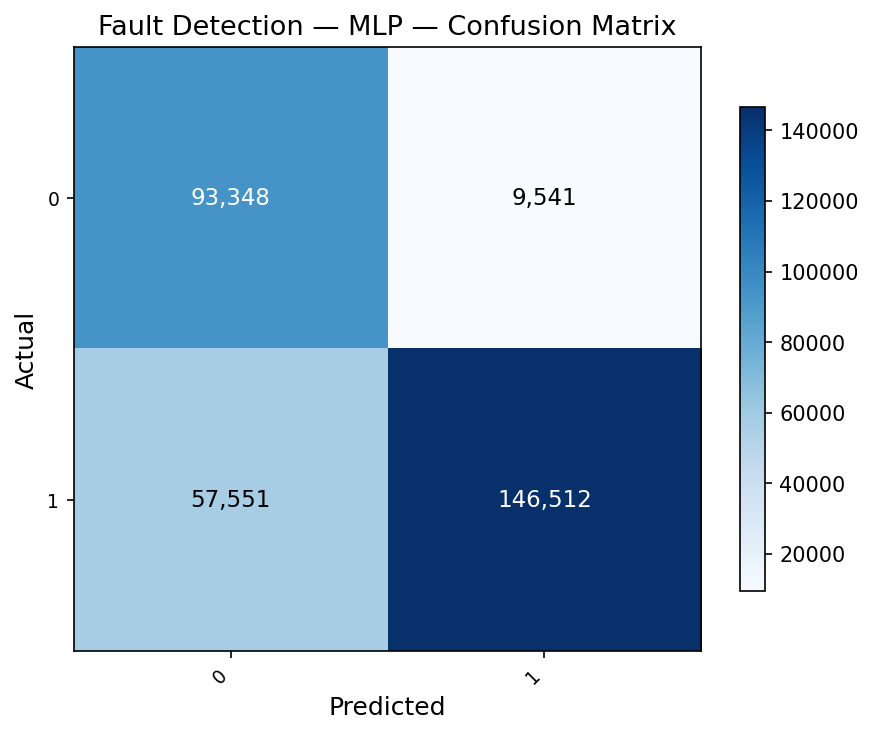


fault_detection — LSTM


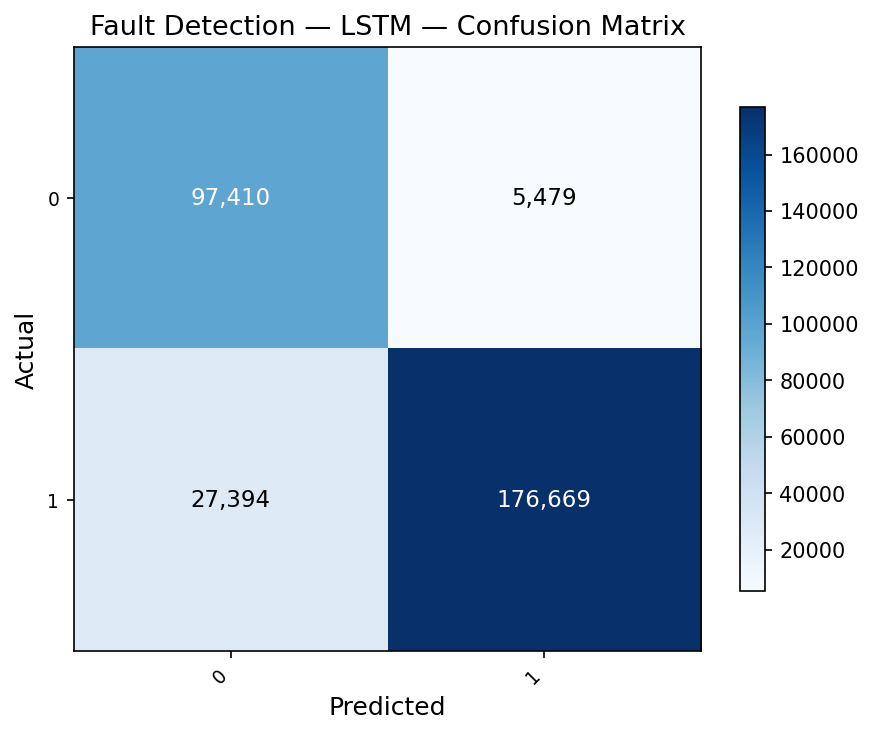


fault_detection — HYBRID


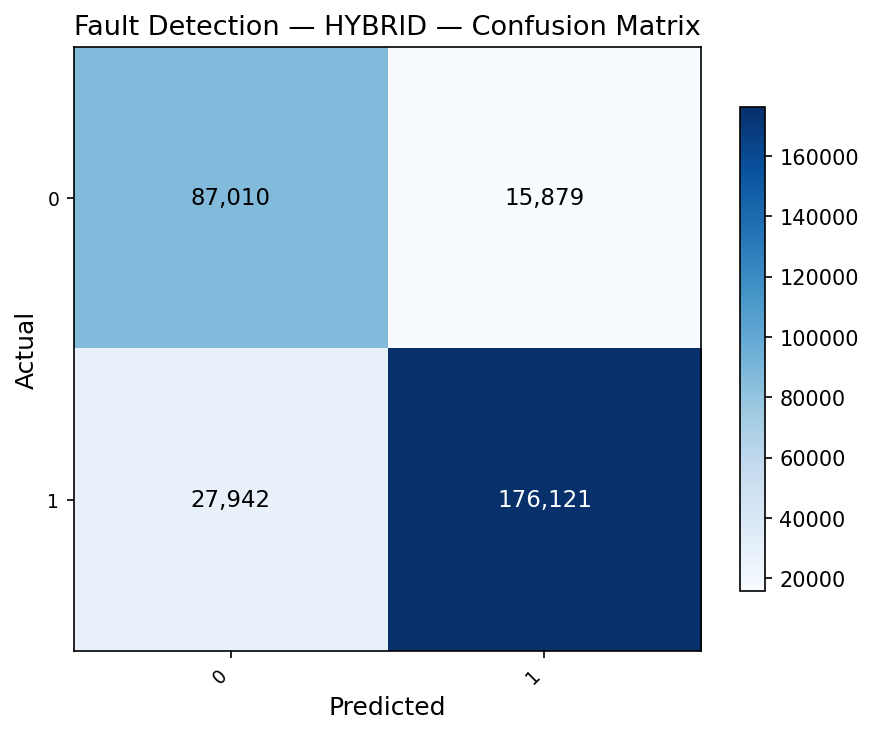


fault_classification — MLP


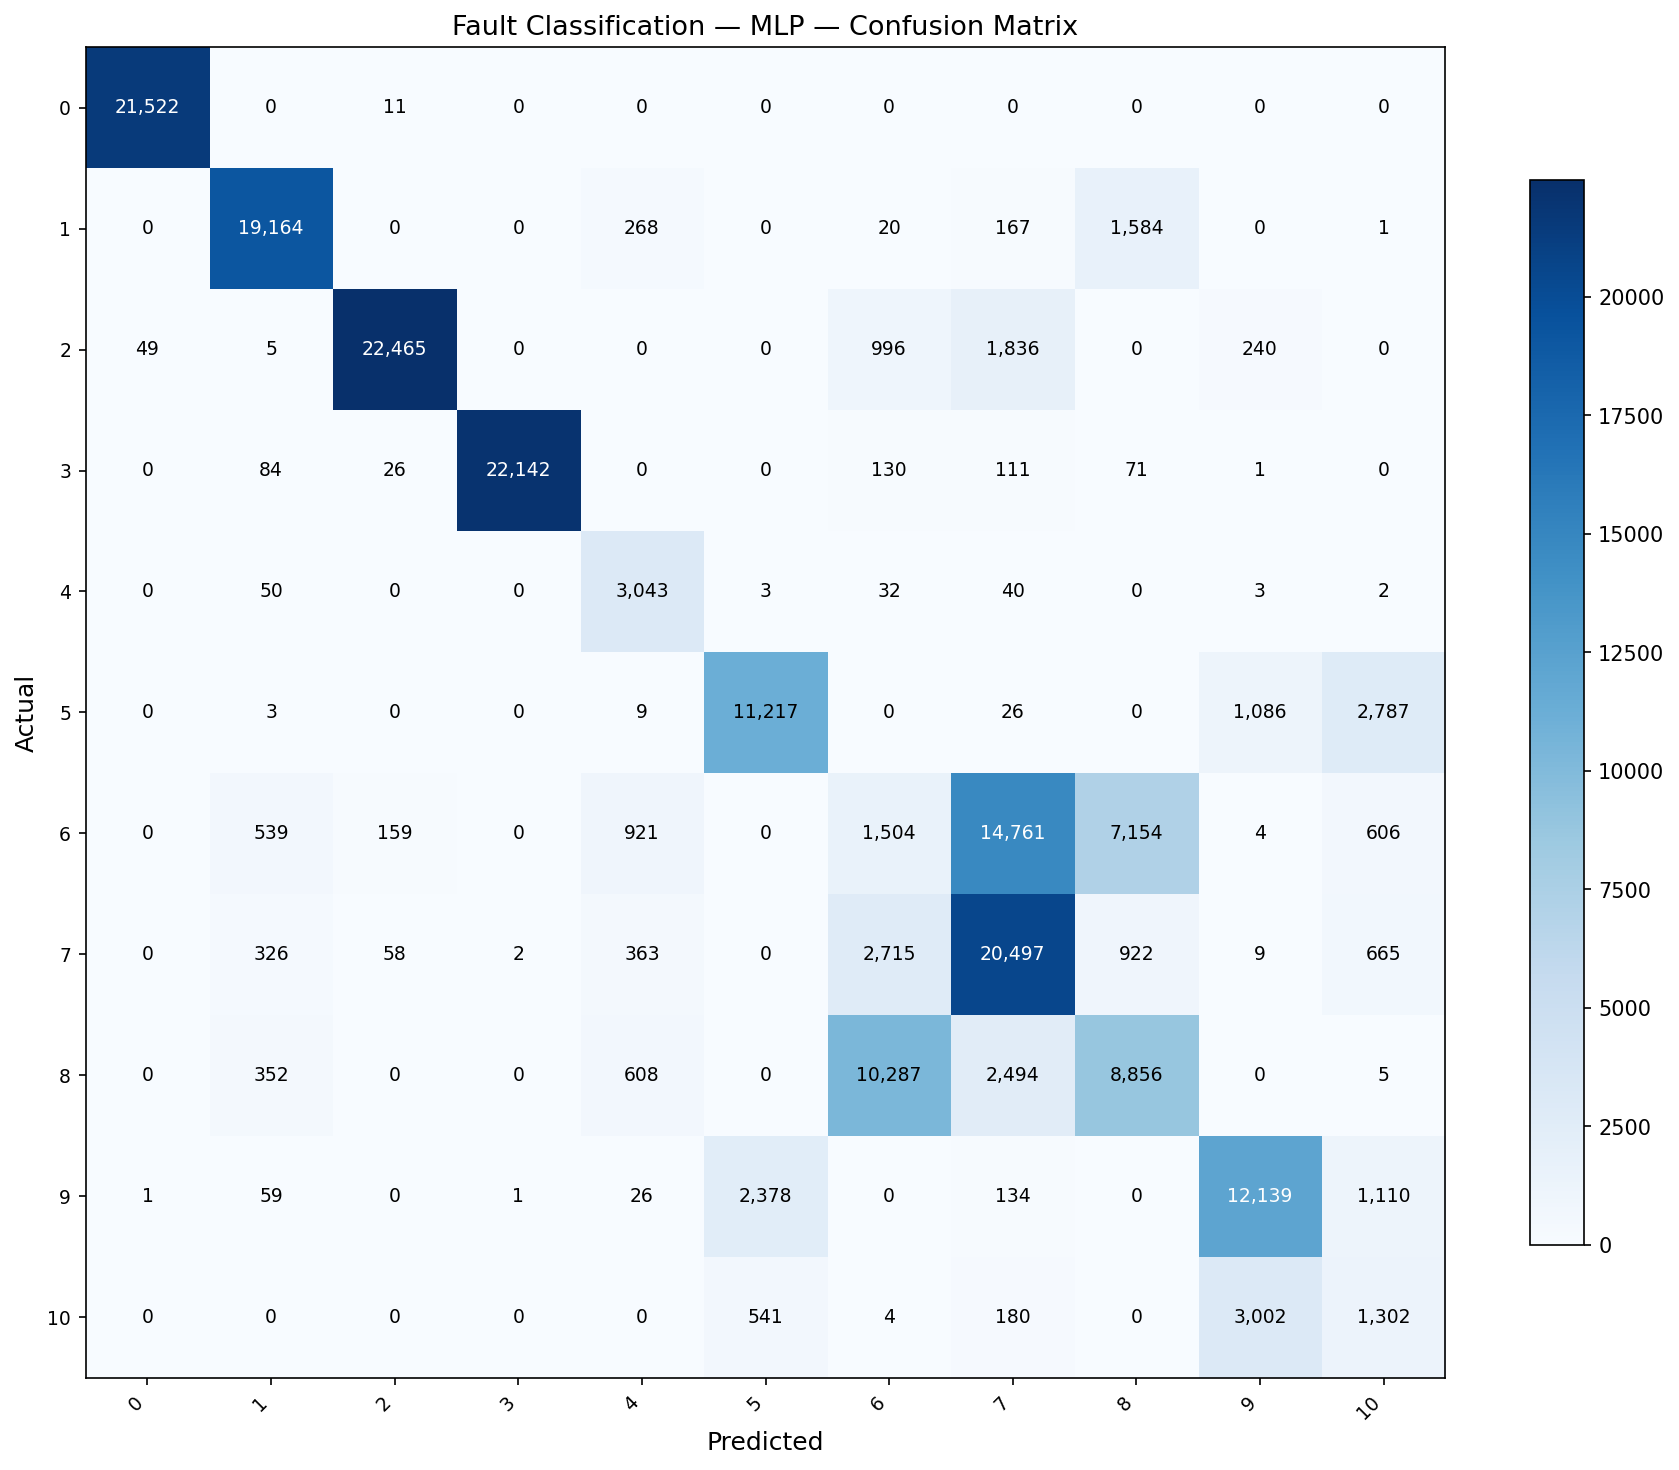


fault_classification — LSTM


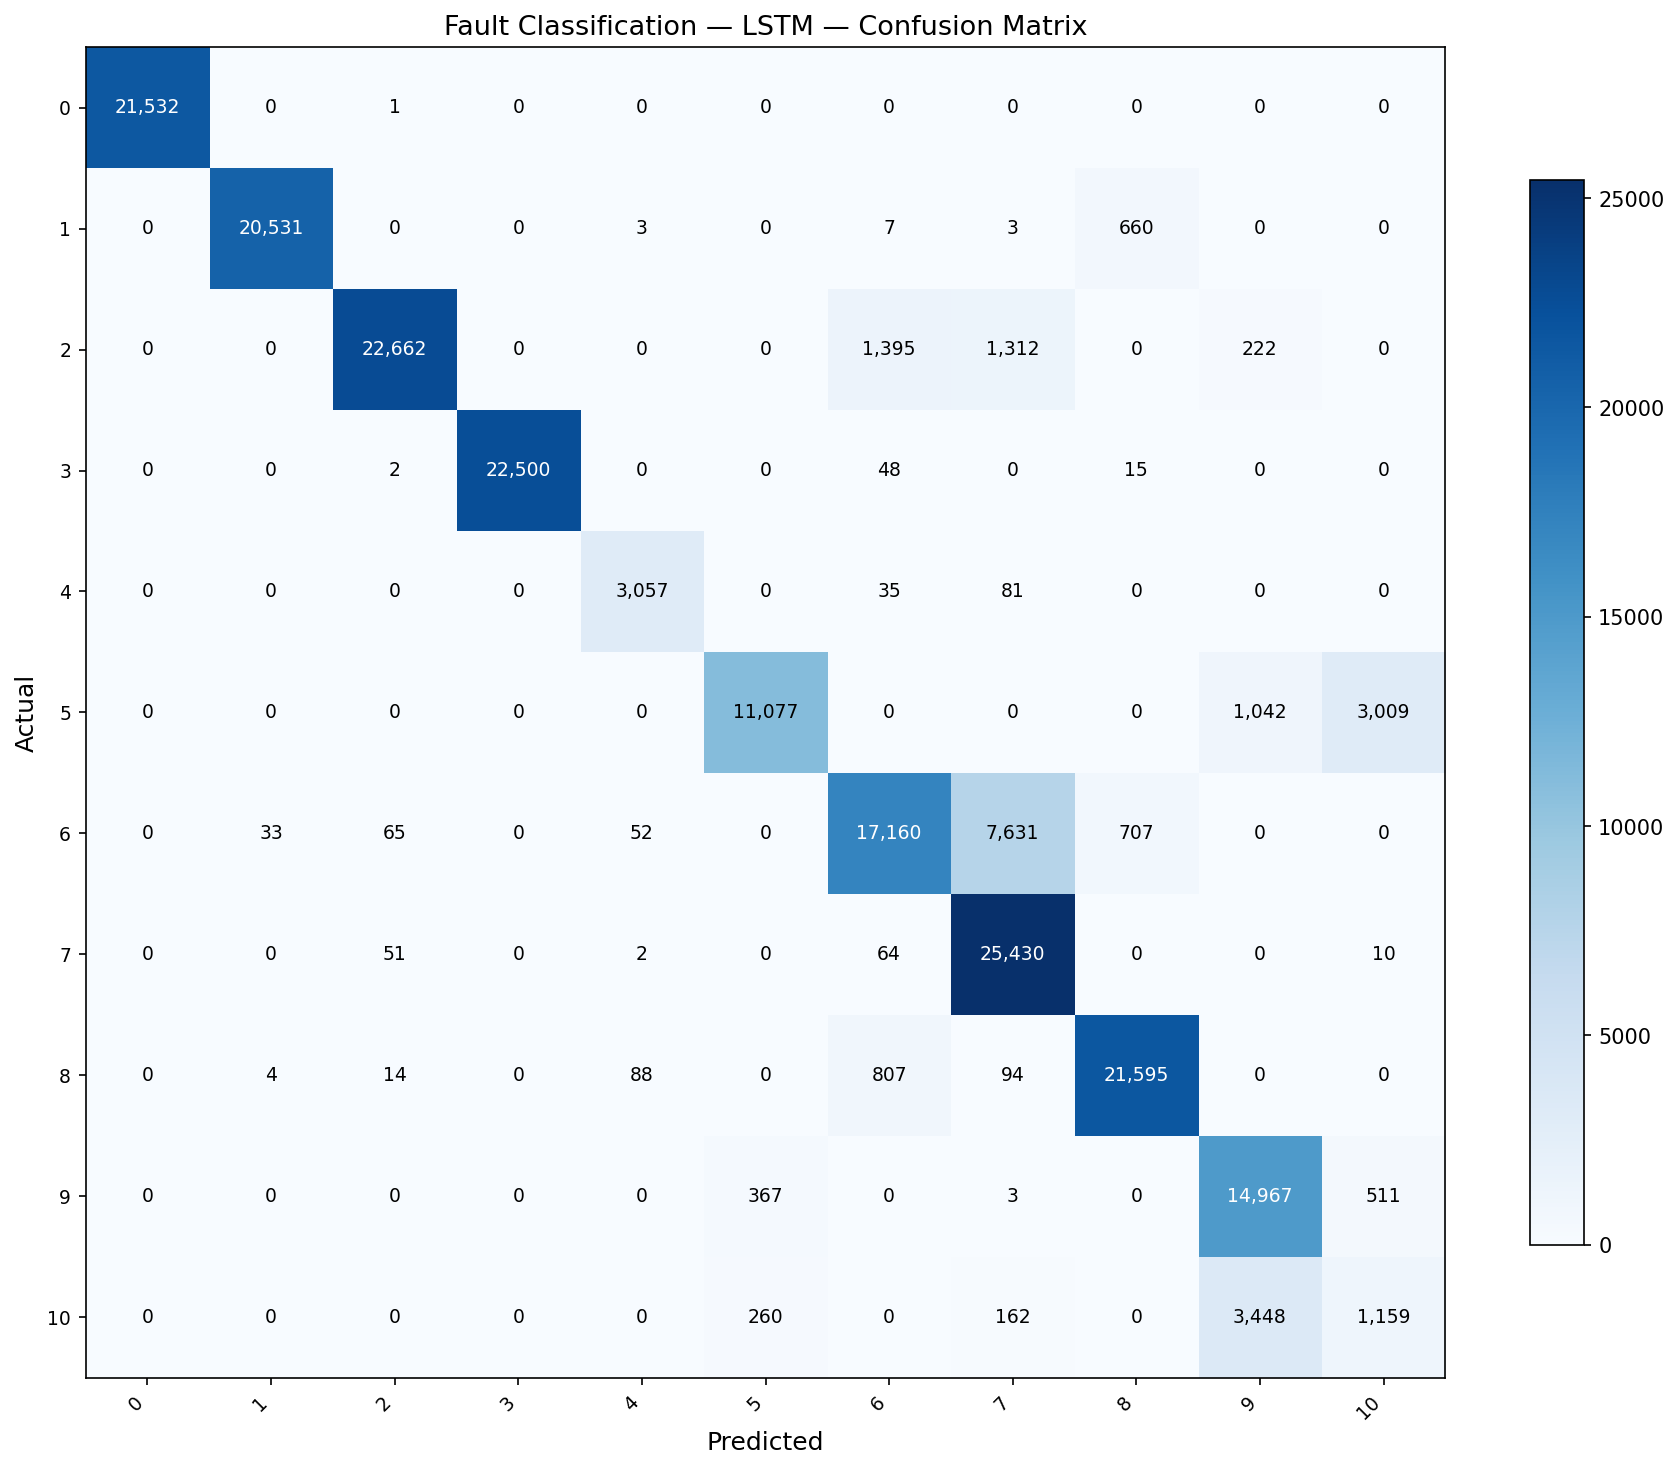


fault_classification — HYBRID


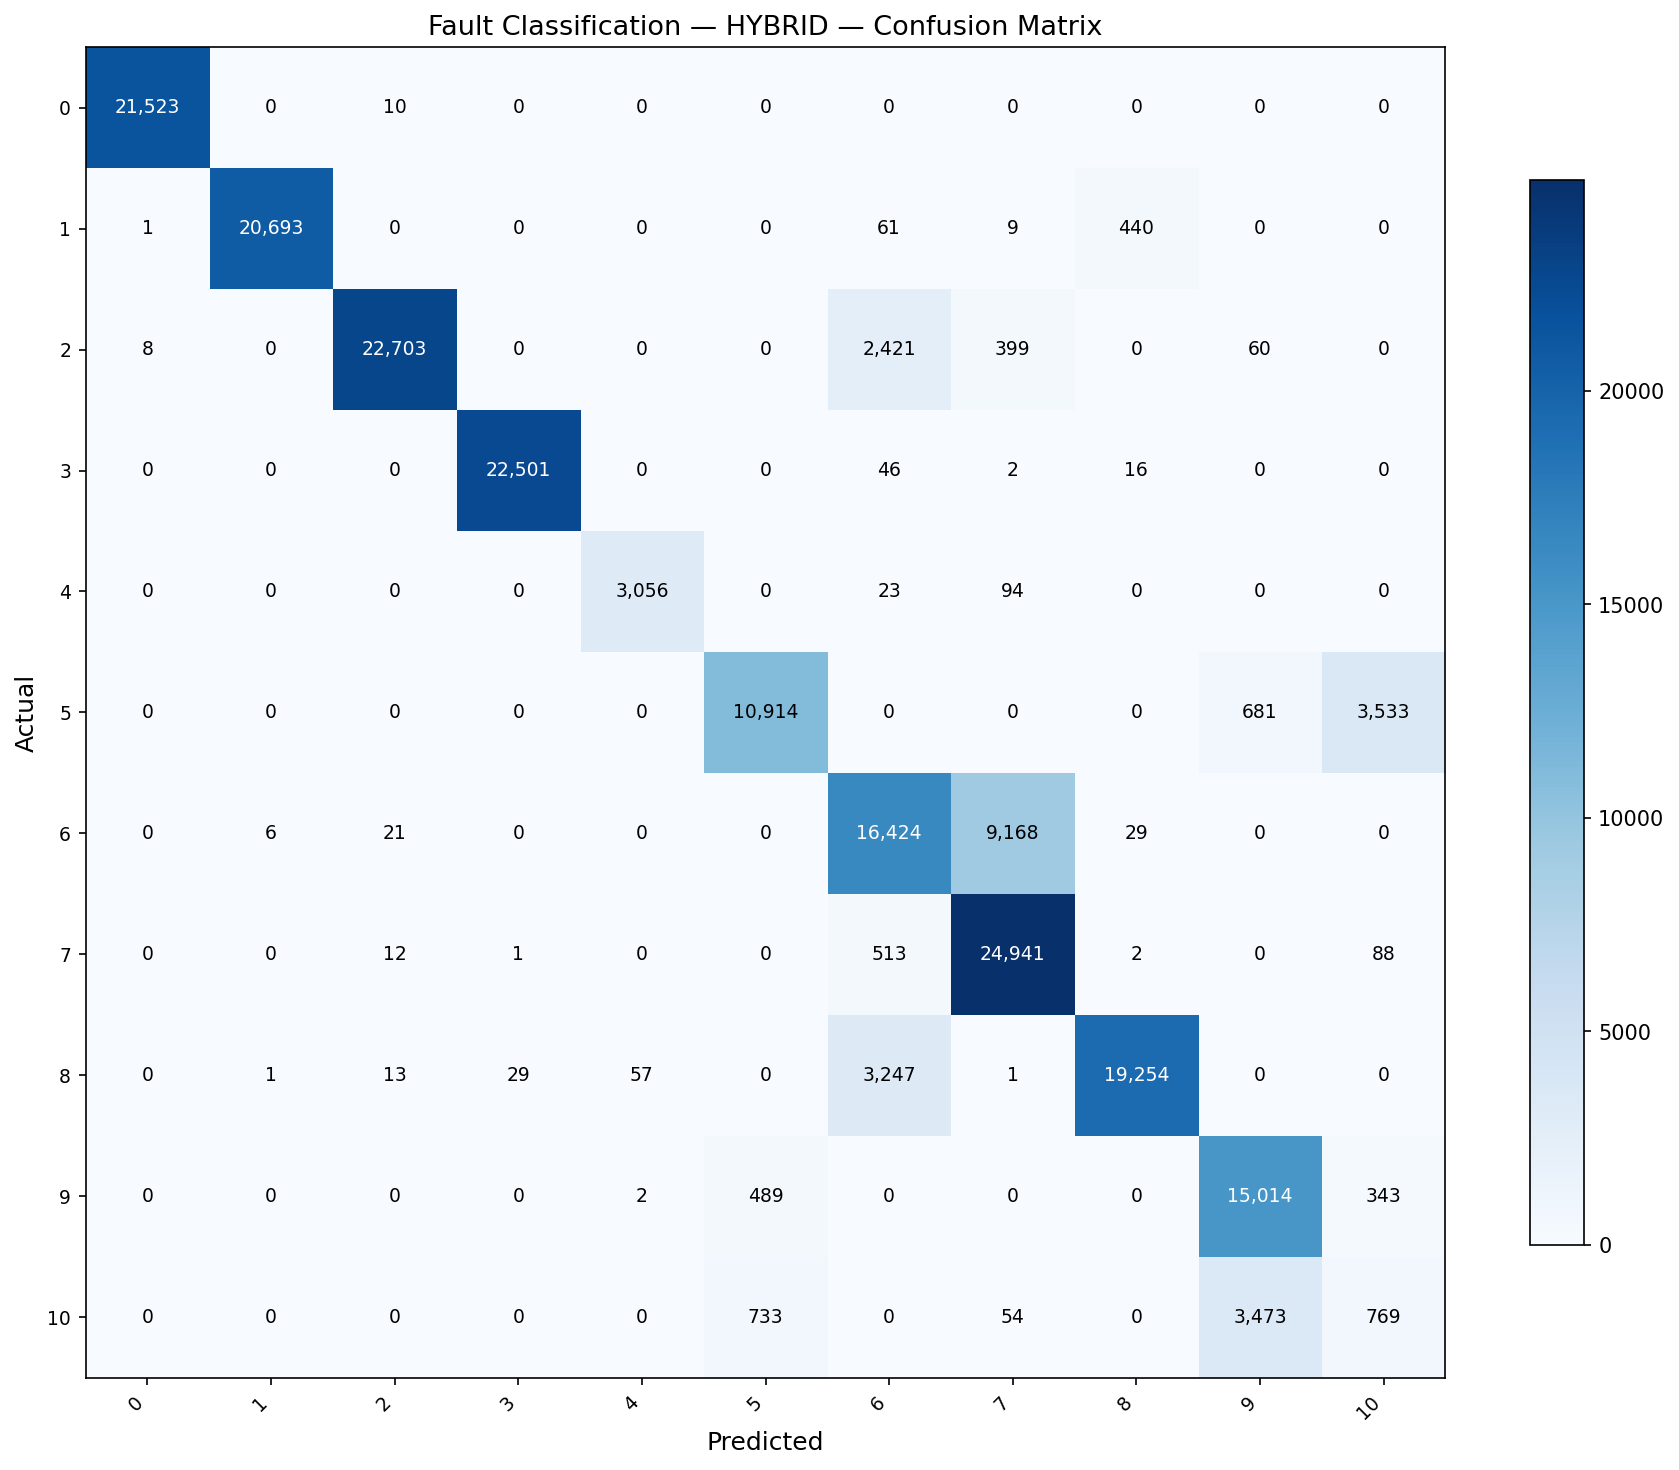

In [10]:
for task_tag in ["fault_detection", "fault_classification"]:
    for mode in MODEL_MODES:
        p = f"{OUTPUT_DIR}/confusion_{task_tag}_{mode}.png"
        if pathlib.Path(p).exists():
            print(f"\n{task_tag} — {mode.upper()}")
            ipy_display(Image(p))


## 8. Saved artifacts

In [11]:
import os
outputs = sorted(pathlib.Path(OUTPUT_DIR).iterdir())
for f in outputs:
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"  {f.name:<50s}  {size_mb:.2f} MB")


  confusion_fault_classification_hybrid.png           0.09 MB
  confusion_fault_classification_lstm.png             0.09 MB
  confusion_fault_classification_mlp.png              0.11 MB
  confusion_fault_detection_hybrid.png                0.04 MB
  confusion_fault_detection_lstm.png                  0.04 MB
  confusion_fault_detection_mlp.png                   0.04 MB
  curves_fault_classification_hybrid.png              0.07 MB
  curves_fault_classification_lstm.png                0.06 MB
  curves_fault_classification_mlp.png                 0.07 MB
  curves_fault_detection_hybrid.png                   0.07 MB
  curves_fault_detection_lstm.png                     0.07 MB
  curves_fault_detection_mlp.png                      0.08 MB
  label_encoder_fault_classification.pkl              0.00 MB
  model_fault_classification_hybrid.pt                0.91 MB
  model_fault_classification_lstm.pt                  0.87 MB
  model_fault_classification_mlp.pt                   0.05 MB
  model_